In [ ]:
import pandas as pd
import numpy as np

# Preprocesamiento de texto
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Division de datos
from sklearn.model_selection import train_test_split

# Construccion del modelo
from tensorflow.keras.models import Sequential

# Capas
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Activation,
    GlobalAveragePooling1D
)

# Regularizacion
from tensorflow.keras.regularizers import l2

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping

# Optimizador
from tensorflow.keras.optimizers import Adam

# Metricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Visualizacion
import matplotlib.pyplot as plt

# Dataset
df = pd.read_csv("IMDB Dataset.csv", on_bad_lines='skip')


In [ ]:
# Este bloque elimina duplicados y transforma la variable objetivo a formato numerico

df = df.drop_duplicates()

df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})


# Este bloque separa las variables de entrada y salida

X = df["review"]
y = df["sentiment"]


# Este bloque define los parametros generales del modelo

max_len = 200


# Este bloque realiza la tokenizacion del texto una sola vez para todos los modelos

tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(X)

sequences = tokenizer.texts_to_sequences(X)

X_pad = pad_sequences(
    sequences,
    maxlen=max_len
)


# Este bloque divide los datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42
)


# Este bloque define la funcion para crear los distintos modelos

def crear_modelo(max_words=10000,
                 usar_pooling=False,
                 learning_rate=0.001,
                 dropout_rate=0.0):

    model = Sequential()

    model.add(Input(shape=(max_len,)))

    model.add(
        Embedding(
            input_dim=max_words,
            output_dim=32
        )
    )


    if usar_pooling:

        model.add(
            GlobalAveragePooling1D()
        )

    else:

        model.add(
            Flatten()
        )


    model.add(
        Dense(
            16,
            activation='relu'
        )
    )


    if dropout_rate > 0:

        model.add(
            Dropout(dropout_rate)
        )


    model.add(
        Dense(
            8,
            activation='relu'
        )
    )


    if dropout_rate > 0:

        model.add(
            Dropout(dropout_rate)
        )


    model.add(
        Dense(
            1,
            activation='sigmoid'
        )
    )


    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )


    return model



# Este bloque define las configuraciones de los modelos a comparar

configuraciones = {

    "Dropout_0.8": {
        "max_words": 10000,
        "usar_pooling": False,
        "learning_rate": 0.001,
        "dropout_rate": 0.8
    },


    "Dropout_0.8_GlobalAveragePooling1D": {
        "max_words": 10000,
        "usar_pooling": True,
        "learning_rate": 0.001,
        "dropout_rate": 0.8
    },


    "Dropout_0.8_LearningRate_0.0005": {
        "max_words": 10000,
        "usar_pooling": False,
        "learning_rate": 0.0005,
        "dropout_rate": 0.8
    },


    "Dropout_0.8_MaxWords_20000": {
        "max_words": 20000,
        "usar_pooling": False,
        "learning_rate": 0.001,
        "dropout_rate": 0.8
    }

}

## Comparacion de Modelos

En esta seccion se entrenan y evaluan cuatro modelos diferentes con el objetivo de comparar como distintos cambios afectan el rendimiento del modelo base desarrollado durante las evaluaciones anteriores del semestre.

Durante las evaluaciones previas se probó el modelo base utilizando distintas configuraciones de normalizacion y regularizacion. A partir de estos experimentos se determino que la mejor configuracion obtenida correspondia al uso de Dropout con una tasa de 0.8. Por esta razon, en esta etapa dicha configuracion se mantiene fija y se utiliza como punto de partida para realizar nuevas comparaciones.

El objetivo de esta evaluacion es analizar si otros cambios en la configuracion del modelo permiten mejorar los resultados obtenidos anteriormente. Para esto, todos los modelos utilizan la misma configuracion de Dropout 0.8, permitiendo que las diferencias observadas se deban principalmente a los cambios realizados en cada experimento.

Los modelos evaluados son:

- El modelo base utilizado en las evaluaciones anteriores del semestre, utilizando la configuracion de Dropout 0.8 obtenida como mejor resultado.
- Un modelo que reemplaza la capa Flatten por GlobalAveragePooling1D, buscando reducir la cantidad de parametros y obtener una representacion mas general del texto.
- Un modelo que modifica el learning rate del optimizador Adam, con el objetivo de analizar si una tasa de aprendizaje mas pequeña permite un entrenamiento mas estable.
- Un modelo que aumenta el tamaño del vocabulario utilizado en la tokenizacion, permitiendo incorporar una mayor cantidad de palabras durante el aprendizaje.

Cada modelo se entrena utilizando la misma division de datos y el mismo proceso de preparacion del texto para que la comparacion sea justa. Luego, su desempeño se evalua mediante las metricas accuracy, precision, recall y F1-score.

Finalmente, se generan graficos de validation loss y validation accuracy para observar el comportamiento de los modelos durante las epocas de entrenamiento y analizar si las modificaciones realizadas permiten mejorar la capacidad de generalizacion frente a datos no utilizados durante el entrenamiento.



Entrenando modelo: Dropout_0.8
Epoch 1/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.5001 - loss: 0.6939 - val_accuracy: 0.5061 - val_loss: 0.6931
Epoch 2/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5085 - loss: 0.6931 - val_accuracy: 0.5857 - val_loss: 0.6906
Epoch 3/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.6028 - loss: 0.6552 - val_accuracy: 0.8298 - val_loss: 0.5076
Epoch 4/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.7078 - loss: 0.5679 - val_accuracy: 0.8123 - val_loss: 0.4695
Epoch 5/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.7451 - loss: 0.5254 - val_accuracy: 0.8650 - val_loss: 0.4058
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Entrenando modelo: Dropout_0.8_GlobalAveragePooling1D
Epoch 1/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4981 - loss: 0.6933 - val_accuracy: 0.5026 - val_loss: 0.6929
Epoch 2/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.5304 - loss: 0.6848 - val_acc

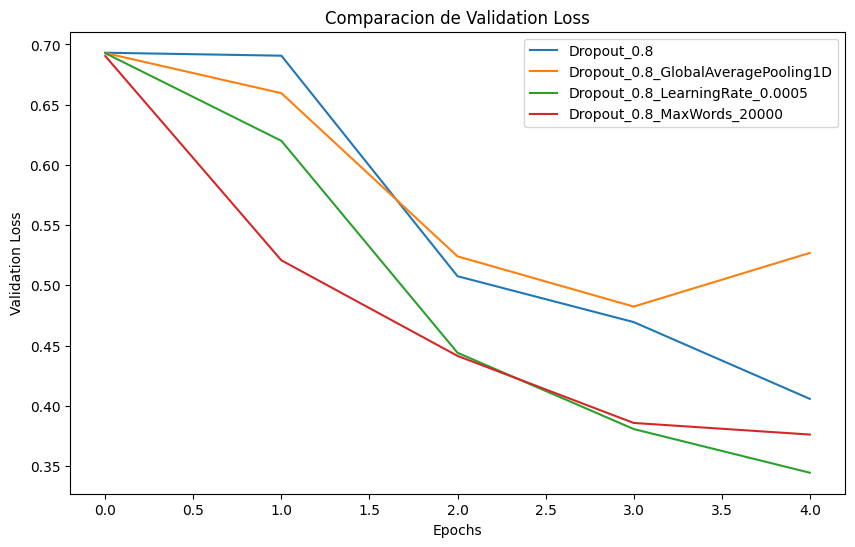

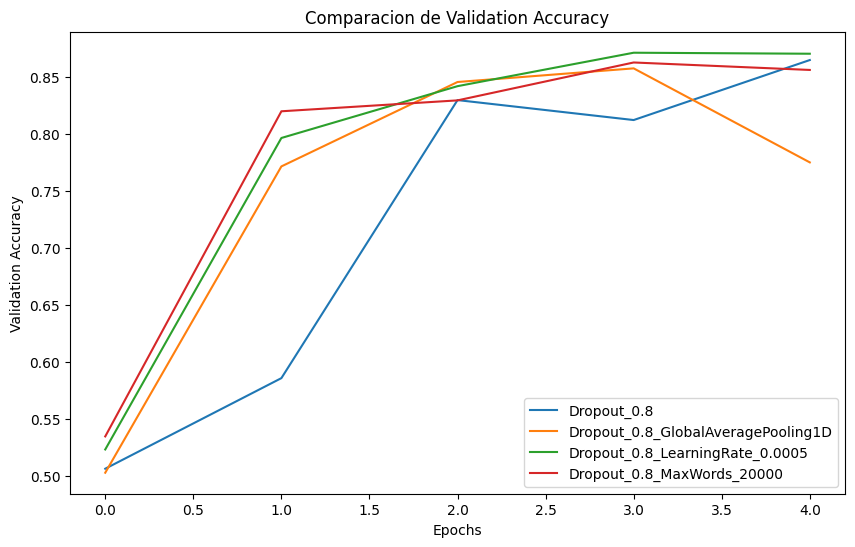

In [ ]:
# Este bloque crea diccionarios para guardar resultados e historiales

resultados = {}

histories = {}


# Este bloque entrena y evalua cada uno de los modelos definidos

for nombre, config in configuraciones.items():

    print("\n")
    print("=" * 60)
    print(f"Entrenando modelo: {nombre}")
    print("=" * 60)


    # Crear modelo

    model = crear_modelo(
        max_words=config["max_words"],
        usar_pooling=config["usar_pooling"],
        learning_rate=config["learning_rate"],
        dropout_rate=config["dropout_rate"]
    )


    # Entrenamiento

    history = model.fit(
        X_train,
        y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )


    histories[nombre] = history


    # Predicciones

    y_pred = model.predict(X_test)

    y_pred = (y_pred > 0.5).astype(int)


    # Calculo de metricas

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )


    resultados[nombre] = {

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1

    }



# Este bloque muestra la tabla comparativa de resultados

print("\n")
print("=" * 70)
print("RESULTADOS FINALES")
print("=" * 70)


resultados_df = pd.DataFrame(resultados).T

print(resultados_df)



# Este bloque grafica la comparacion de validation loss

plt.figure(figsize=(10,6))

for nombre, history in histories.items():

    plt.plot(
        history.history["val_loss"],
        label=nombre
    )


plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Comparacion de Validation Loss")
plt.legend()
plt.show()



# Este bloque grafica la comparacion de validation accuracy

plt.figure(figsize=(10,6))

for nombre, history in histories.items():

    plt.plot(
        history.history["val_accuracy"],
        label=nombre
    )


plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Comparacion de Validation Accuracy")
plt.legend()
plt.show()

## Conclusion

En esta evaluacion se realizaron distintas modificaciones sobre el modelo base desarrollado durante el semestre con el objetivo de analizar si era posible mejorar su rendimiento mediante cambios en la configuracion del modelo.

Como punto de partida se utilizo la mejor configuracion obtenida en evaluaciones anteriores, donde el uso de Dropout con una tasa de 0.8 entrego los mejores resultados frente a otras alternativas de regularizacion. Manteniendo esta configuracion fija, se evaluaron cambios relacionados con la arquitectura del modelo, el learning rate y el tamaño del vocabulario utilizado.

Los resultados mostraron que no todas las modificaciones generaron mejoras. El cambio a GlobalAveragePooling1D redujo el rendimiento general del modelo, principalmente debido a una disminucion en el recall, lo que indica que el modelo tuvo mayores dificultades para identificar correctamente algunos ejemplos positivos. Por otro lado, aumentar el tamaño del vocabulario permitió mejorar la precision, aunque no logró superar el balance general obtenido por el modelo base.

La modificacion que obtuvo mejores resultados fue la reduccion del learning rate a 0.0005. Este modelo alcanzó el mayor accuracy y F1-score entre las configuraciones evaluadas, mostrando una mejora respecto al modelo base. Esto indica que un ajuste en la velocidad de aprendizaje puede ayudar al modelo a encontrar una mejor solucion durante el entrenamiento sin necesidad de modificar completamente su estructura.

En conclusion, los experimentos realizados permitieron observar como pequeños cambios en la configuracion de una red neuronal pueden afectar su capacidad de aprendizaje y generalizacion. Si bien las mejoras obtenidas fueron moderadas, el proceso demuestra la importancia de evaluar distintas configuraciones y comparar sus resultados mediante metricas adecuadas antes de seleccionar un modelo final.